# 3.1 Detection Phase: Hierarchical Fake News Detection

This notebook implements the **Detection Phase** in the proposal with a hierarchical pipeline:

1. **Baseline model:** `TF-IDF + Passive Aggressive Classifier (PAC)` (online-style training with `partial_fit`).
2. **Deep model:** `RoBERTa` for semantic understanding.
3. **Hierarchical routing:** PAC handles high-confidence samples, RoBERTa handles low-confidence samples.

## Data

```python
from datasets import load_dataset

ds1 = load_dataset("GonzaloA/fake_news")
ds2 = load_dataset("chengxuphd/liar2")
```

### Label strategy

- `ds1` is already binary.
- `ds2` has 6 labels. To reduce noise for binary training, we keep only high-confidence labels:
  - `0, 1 -> fake (0)`
  - `4, 5 -> real (1)`
  - `2, 3` are dropped as ambiguous middle classes.


In [1]:
uv pip install datasets

Using Python 3.12.6 environment at: /usr/local
Resolved 36 packages in 835ms
⠙ Preparing packages... (0/5)
⠙ Preparing packages... (0/5)
⠙ Preparing packages... (0/5)
⠙ Preparing packages... (0/5)
⠙ Preparing packages... (0/5)
⠙ Preparing packages... (0/5)
⠙ Preparing packages... (0/5)
dill       ------------------------------ 80.00 KiB/116.86 KiB
⠙ Preparing packages... (0/5)
dill       ------------------------------ 96.00 KiB/116.86 KiB
⠙ Preparing packages... (0/5)
dill       ------------------------------ 96.00 KiB/116.86 KiB
xxhash     ------------------------------     0 B/189.34 KiB
⠙ Preparing packages... (0/5)
dill       ------------------------------ 96.00 KiB/116.86 KiB
xxhash     ------------------------------ 14.91 KiB/189.34 KiB
⠙ Preparing packages... (0/5)
dill       ------------------------------ 101.43 KiB/116.86 KiB
xxhash     ------------------------------ 14.91 KiB/189.34 KiB
⠙ Preparing packages... (0/5)
dill       ------------------------------ 116.86 KiB/116.86 

In [2]:
!mkdir -p generated && mv -f generated.zip generated/ && unzip -o generated/generated.zip -d generated

Archive:  generated/generated.zip
  inflating: generated/adsent_generated.csv  
  inflating: generated/__MACOSX/._adsent_generated.csv  
  inflating: generated/cot_generated.csv  
  inflating: generated/__MACOSX/._cot_generated.csv  
  inflating: generated/SheepDog_generated.csv  
  inflating: generated/__MACOSX/._SheepDog_generated.csv  


In [3]:
import os
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from datasets import Dataset, load_dataset
from joblib import dump
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Torch version: {torch.__version__}")




Device: cuda
Torch version: 2.8.0+cu129


In [4]:
ds1 = load_dataset("GonzaloA/fake_news")
ds2 = load_dataset("chengxuphd/liar2")
ds3 = load_dataset("ArkaMukherjee/Uni-Fakeddit-55k", streaming=True)

print(ds1)
print(ds2)
print(ds3)



README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/38.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/13.0M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/18369 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2297 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2296 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/161 [00:00<?, ?B/s]

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 24353
    })
    validation: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 8117
    })
    test: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 8117
    })
})
DatasetDict({
    train: Dataset({
        features: ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts', 'context', 'justification'],
        num_rows: 18369
    })
    validation: Dataset({
        features: ['id', 'label', 'statement', 'date', 'subject', 'speaker', 'speaker_description', 'state_info', 'true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts', 'context', 'justification'],
        num_rows: 2297
    

In [5]:
LIAR_FALSE_LABELS = {0, 1}
LIAR_TRUE_LABELS = {4, 5}

UF_FALSE_LABELS = {0}
UF_TRUE_LABELS = {1, 2}
UF_PATTERN = re.compile(
    r"\[TEXT\]\s*(.*?)\s*\[OBJECTS\]\s*(.*?)\s*\[LABEL\]\s*(\d+)\s*$",
    flags=re.IGNORECASE,
)


def clean_text(value):
    if value is None:
        return ""
    value = str(value).replace("\n", " ").strip()
    return " ".join(value.split())


def parse_unifakeddit_record(raw_text):
    if raw_text is None:
        return None

    match = UF_PATTERN.match(str(raw_text).strip())
    if match is None:
        return None

    text_part = clean_text(match.group(1))
    objects_part = clean_text(match.group(2).replace(",", " "))
    raw_label = int(match.group(3))

    if raw_label in UF_FALSE_LABELS:
        label = 0
    elif raw_label in UF_TRUE_LABELS:
        label = 1
    else:
        return None

    if not text_part and not objects_part:
        return None

    fused_text = text_part if not objects_part else f"{text_part} [objects] {objects_part}"
    return {
        "text": fused_text,
        "label": label,
        "source": "ds3_uni_fakeddit",
        "raw_label": raw_label,
    }


def preprocess_ds1(split_name):
    rows = []
    for ex in ds1[split_name]:
        text = clean_text(f"{ex['title']} {ex['text']}")
        if not text:
            continue
        rows.append(
            {
                "text": text,
                "label": int(ex["label"]),
                "source": "ds1",
            }
        )
    return pd.DataFrame(rows)


def preprocess_ds2(split_name):
    rows = []
    for ex in ds2[split_name]:
        raw_label = int(ex["label"])
        if raw_label in LIAR_FALSE_LABELS:
            label = 0
        elif raw_label in LIAR_TRUE_LABELS:
            label = 1
        else:
            continue

        text = clean_text(ex["statement"])
        if not text:
            continue

        rows.append(
            {
                "text": text,
                "label": label,
                "source": "ds2",
            }
        )
    return pd.DataFrame(rows)


def preprocess_ds3():
    rows = []
    for ex in ds3["train"]:
        parsed = parse_unifakeddit_record(ex.get("text"))
        if parsed is not None:
            rows.append(parsed)

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
    return df




In [6]:
def stratified_three_way_split(df, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, seed=SEED):
    total = train_ratio + val_ratio + test_ratio
    if not np.isclose(total, 1.0):
        raise ValueError("train/val/test ratios must sum to 1.0")

    splitter_1 = StratifiedShuffleSplit(
        n_splits=1,
        test_size=(1.0 - train_ratio),
        random_state=seed,
    )
    train_idx, holdout_idx = next(splitter_1.split(df["text"], df["label"]))

    train_part = df.iloc[train_idx].reset_index(drop=True)
    holdout = df.iloc[holdout_idx].reset_index(drop=True)

    holdout_test_ratio = test_ratio / (val_ratio + test_ratio)
    splitter_2 = StratifiedShuffleSplit(
        n_splits=1,
        test_size=holdout_test_ratio,
        random_state=seed,
    )
    val_idx, test_idx = next(splitter_2.split(holdout["text"], holdout["label"]))

    val_part = holdout.iloc[val_idx].reset_index(drop=True)
    test_part = holdout.iloc[test_idx].reset_index(drop=True)

    return {
        "train": train_part,
        "validation": val_part,
        "test": test_part,
    }


ds3_full = preprocess_ds3()
print(f"[Uni-Fakeddit-55k] parsed total={len(ds3_full)}")
if not ds3_full.empty:
    print("[Uni-Fakeddit-55k] raw label distribution:", ds3_full["raw_label"].value_counts().sort_index().to_dict())
    print("[Uni-Fakeddit-55k] binary label distribution:", ds3_full["label"].value_counts().sort_index().to_dict())

    ds3_splits = stratified_three_way_split(ds3_full[["text", "label", "source"]])
else:
    ds3_splits = {"train": pd.DataFrame(columns=["text", "label", "source"]),
                  "validation": pd.DataFrame(columns=["text", "label", "source"]),
                  "test": pd.DataFrame(columns=["text", "label", "source"])}

splits = {}
for split_name in ["train", "validation", "test"]:
    part_ds1 = preprocess_ds1(split_name)
    part_ds2 = preprocess_ds2(split_name)
    part_ds3 = ds3_splits[split_name]

    merged = pd.concat([part_ds1, part_ds2, part_ds3], ignore_index=True)
    merged = merged.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    splits[split_name] = merged

    print(f"\n[{split_name}] total={len(merged)}")
    print("source distribution:", merged["source"].value_counts().to_dict())
    print("label distribution:", merged["label"].value_counts().to_dict())

train_df = splits["train"]
val_df = splits["validation"]
test_df = splits["test"]




[Uni-Fakeddit-55k] parsed total=54691
[Uni-Fakeddit-55k] raw label distribution: {0: 32795, 1: 21896}
[Uni-Fakeddit-55k] binary label distribution: {0: 32795, 1: 21896}

[train] total=80625
source distribution: {'ds3_uni_fakeddit': 43752, 'ds1': 24353, 'ds2': 12520}
label distribution: {0: 45103, 1: 35522}

[validation] total=15151
source distribution: {'ds1': 8117, 'ds3_uni_fakeddit': 5469, 'ds2': 1565}
label distribution: {0: 7966, 1: 7185}

[test] total=15152
source distribution: {'ds1': 8117, 'ds3_uni_fakeddit': 5470, 'ds2': 1565}
label distribution: {0: 8025, 1: 7127}


## Baseline: TF-IDF + Passive Aggressive (Online-Style)

We train PAC incrementally with `partial_fit` over mini-batches to mimic streaming updates.


In [7]:
def binary_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0,
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def print_metrics(title, metrics):
    print(f"{title}")
    for key, value in metrics.items():
        print(f"  {key}: {value:.4f}")


tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.98,
    max_features=200000,
    sublinear_tf=True,
)

X_train = tfidf.fit_transform(train_df["text"])
X_val = tfidf.transform(val_df["text"])
X_test = tfidf.transform(test_df["text"])

y_train = train_df["label"].to_numpy()
y_val = val_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train,
)
class_weight_dict = {0: class_weight_values[0], 1: class_weight_values[1]}
print("PAC class weights:", class_weight_dict)

pac = PassiveAggressiveClassifier(
    C=0.35,
    max_iter=1,
    tol=None,
    random_state=SEED,
    class_weight=class_weight_dict,
)

PAC_EPOCHS = 5
PAC_BATCH_SIZE = 4096
classes = np.array([0, 1])
rng = np.random.default_rng(SEED)

for epoch in range(PAC_EPOCHS):
    order = rng.permutation(X_train.shape[0])
    for start in range(0, len(order), PAC_BATCH_SIZE):
        idx = order[start : start + PAC_BATCH_SIZE]
        kwargs = {"classes": classes} if (epoch == 0 and start == 0) else {}
        pac.partial_fit(X_train[idx], y_train[idx], **kwargs)

pac_val_pred = pac.predict(X_val)
pac_test_pred = pac.predict(X_test)

pac_val_metrics = binary_metrics(y_val, pac_val_pred)
pac_test_metrics = binary_metrics(y_test, pac_test_pred)

print_metrics("PAC validation", pac_val_metrics)
print_metrics("PAC test", pac_test_metrics)

print("\nPAC test classification report:")
print(classification_report(y_test, pac_test_pred, digits=4))




PAC class weights: {0: np.float64(0.8937875529343946), 1: np.float64(1.1348600867068295)}
PAC validation
  accuracy: 0.8517
  precision: 0.8476
  recall: 0.8380
  f1: 0.8427
PAC test
  accuracy: 0.8545
  precision: 0.8479
  recall: 0.8417
  f1: 0.8448

PAC test classification report:
              precision    recall  f1-score   support

           0     0.8603    0.8659    0.8631      8025
           1     0.8479    0.8417    0.8448      7127

    accuracy                         0.8545     15152
   macro avg     0.8541    0.8538    0.8540     15152
weighted avg     0.8545    0.8545    0.8545     15152



## Deep Learning: RoBERTa

To keep notebook runtime practical, RoBERTa is trained on a stratified subset. You can increase sample sizes later.


In [8]:
def stratified_downsample(df, n_samples, seed=SEED):
    if n_samples is None or n_samples >= len(df):
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    splitter = StratifiedShuffleSplit(n_splits=1, train_size=n_samples, random_state=seed)
    sampled_idx, _ = next(splitter.split(df["text"], df["label"]))
    return df.iloc[sampled_idx].sample(frac=1.0, random_state=seed).reset_index(drop=True)


ROBERTA_TRAIN_MAX_SAMPLES = 32000
ROBERTA_EVAL_MAX_SAMPLES = 6000

ROBERTA_TRAIN_SAMPLES = min(ROBERTA_TRAIN_MAX_SAMPLES, len(train_df))
ROBERTA_VAL_SAMPLES = min(ROBERTA_EVAL_MAX_SAMPLES, len(val_df))
ROBERTA_TEST_SAMPLES = min(ROBERTA_EVAL_MAX_SAMPLES, len(test_df))

roberta_train_df = stratified_downsample(train_df, ROBERTA_TRAIN_SAMPLES)
roberta_val_df = stratified_downsample(val_df, ROBERTA_VAL_SAMPLES)
roberta_test_df = stratified_downsample(test_df, ROBERTA_TEST_SAMPLES)

for name, df_part in [
    ("roberta_train", roberta_train_df),
    ("roberta_val", roberta_val_df),
    ("roberta_test", roberta_test_df),
]:
    print(f"{name}: {len(df_part)}")
    print(" label distribution:", df_part["label"].value_counts().to_dict())




roberta_train: 32000
 label distribution: {0: 17901, 1: 14099}
roberta_val: 6000
 label distribution: {0: 3155, 1: 2845}
roberta_test: 6000
 label distribution: {0: 3178, 1: 2822}


In [9]:
MODEL_NAME = "roberta-large"
MAX_LENGTH = 192


def to_hf_dataset(df):
    return Dataset.from_pandas(df[["text", "label"]], preserve_index=False)


hf_train = to_hf_dataset(roberta_train_df)
hf_val = to_hf_dataset(roberta_val_df)
hf_test = to_hf_dataset(roberta_test_df)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )


tok_train = hf_train.map(tokenize_batch, batched=True, remove_columns=["text"])
tok_val = hf_val.map(tokenize_batch, batched=True, remove_columns=["text"])
tok_test = hf_test.map(tokenize_batch, batched=True, remove_columns=["text"])

for ds in [tok_train, tok_val, tok_test]:
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.config.use_cache = False




tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
def hf_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return binary_metrics(labels, preds)


roberta_output_dir = "artifacts/roberta_large_detection"
os.makedirs(roberta_output_dir, exist_ok=True)

training_args = TrainingArguments(
    output_dir=roberta_output_dir,
    num_train_epochs=3,
    learning_rate=1e-5,
    weight_decay=0.03,
    warmup_ratio=0.06,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=512,
    gradient_accumulation_steps=1,
    gradient_checkpointing=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=25,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tok_train,
    eval_dataset=tok_val,
    tokenizer=tokenizer,
    compute_metrics=hf_compute_metrics,
)

trainer.train()




/tmp/ipykernel_472/847642041.py:32: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
/usr/local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.284700,0.201168,0.907667,0.888437,0.920914,0.904384
2,0.257400,0.190945,0.915667,0.890224,0.937786,0.913386
3,0.197100,0.190439,0.921833,0.904357,0.933919,0.918900


/usr/local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=750, training_loss=0.28475104649861654, metrics={'train_runtime': 1079.072, 'train_samples_per_second': 88.965, 'train_steps_per_second': 0.695, 'total_flos': 3.3549529079808e+16, 'train_loss': 0.28475104649861654, 'epoch': 3.0})

In [11]:
val_out = trainer.predict(tok_val)
test_out = trainer.predict(tok_test)

roberta_val_pred = np.argmax(val_out.predictions, axis=-1)
roberta_test_pred = np.argmax(test_out.predictions, axis=-1)

y_val_small = roberta_val_df["label"].to_numpy()
y_test_small = roberta_test_df["label"].to_numpy()

roberta_val_metrics = binary_metrics(y_val_small, roberta_val_pred)
roberta_test_metrics = binary_metrics(y_test_small, roberta_test_pred)

print_metrics("RoBERTa-Large validation", roberta_val_metrics)
print_metrics("RoBERTa-Large test", roberta_test_metrics)




/usr/local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


/usr/local/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


RoBERTa-Large validation
  accuracy: 0.9218
  precision: 0.9044
  recall: 0.9339
  f1: 0.9189
RoBERTa-Large test
  accuracy: 0.9197
  precision: 0.9018
  recall: 0.9305
  f1: 0.9159


## Hierarchical Detection

Routing rule:

- If PAC confidence (`|decision_function|`) is high, keep PAC prediction.
- If PAC confidence is low, defer to RoBERTa.

Threshold is selected on the validation subset.


In [12]:
X_val_small = tfidf.transform(roberta_val_df["text"])
X_test_small = tfidf.transform(roberta_test_df["text"])

pac_val_scores_small = pac.decision_function(X_val_small)
pac_test_scores_small = pac.decision_function(X_test_small)

pac_val_pred_small = (pac_val_scores_small >= 0).astype(int)
pac_test_pred_small = (pac_test_scores_small >= 0).astype(int)

pac_val_small_metrics = binary_metrics(y_val_small, pac_val_pred_small)
pac_test_small_metrics = binary_metrics(y_test_small, pac_test_pred_small)

abs_scores = np.abs(pac_val_scores_small)
quantiles = np.quantile(abs_scores, np.linspace(0.05, 0.95, 19))
threshold_candidates = np.unique(
    np.concatenate(([0.0], quantiles, [abs_scores.max() + 1e-9]))
)

best_threshold = 0.0
best_val_metrics = None
best_val_f1 = -1.0

for thr in threshold_candidates:
    hybrid_val_pred = np.where(abs_scores >= thr, pac_val_pred_small, roberta_val_pred)
    metrics = binary_metrics(y_val_small, hybrid_val_pred)
    if metrics["f1"] > best_val_f1:
        best_val_f1 = metrics["f1"]
        best_threshold = thr
        best_val_metrics = metrics

hybrid_test_pred = np.where(
    np.abs(pac_test_scores_small) >= best_threshold,
    pac_test_pred_small,
    roberta_test_pred,
)
hybrid_test_metrics = binary_metrics(y_test_small, hybrid_test_pred)

route_to_roberta_ratio = float(np.mean(np.abs(pac_test_scores_small) < best_threshold))

print(f"Best threshold (from validation): {best_threshold:.6f}")
print(f"Test routing ratio to RoBERTa-Large: {route_to_roberta_ratio:.4f}")

comparison = pd.DataFrame(
    [
        {"model": "PAC (subset)", **pac_test_small_metrics},
        {"model": "RoBERTa-Large", **roberta_test_metrics},
        {"model": "Hybrid PAC->RoBERTa-Large", **hybrid_test_metrics},
    ]
)
comparison




Best threshold (from validation): 1.987724
Test routing ratio to RoBERTa-Large: 0.6623


,model,accuracy,precision,recall,f1
0,PAC (subset),0.851167,0.846568,0.834869,0.840678
1,RoBERTa-Large,0.919667,0.901786,0.930546,0.915940
2,Hybrid PAC->RoBERTa-Large,0.918500,0.901273,0.928420,0.914645


In [13]:
ARTIFACT_DIR = Path("artifacts/3_1_detection_phase")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

dump(tfidf, ARTIFACT_DIR / "tfidf_vectorizer.joblib")
dump(pac, ARTIFACT_DIR / "pac_classifier.joblib")

trainer.save_model(str(ARTIFACT_DIR / "roberta_model"))
tokenizer.save_pretrained(str(ARTIFACT_DIR / "roberta_model"))
comparison.to_csv(ARTIFACT_DIR / "metrics_comparison.csv", index=False)

print(f"Saved artifacts to: {ARTIFACT_DIR.resolve()}")



Saved artifacts to: /root/artifacts/3_1_detection_phase


In [14]:
def hierarchical_predict(texts):
    if isinstance(texts, str):
        texts = [texts]

    clean_texts = [clean_text(t) for t in texts]

    X = tfidf.transform(clean_texts)
    pac_scores = pac.decision_function(X)
    pac_pred = (pac_scores >= 0).astype(int)

    enc = tokenizer(
        clean_texts,
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    enc = {k: v.to(model.device) for k, v in enc.items()}

    with torch.no_grad():
        logits = model(**enc).logits
        roberta_pred = torch.argmax(logits, dim=-1).cpu().numpy()

    final_pred = np.where(np.abs(pac_scores) >= best_threshold, pac_pred, roberta_pred)

    result_df = pd.DataFrame(
        {
            "text": clean_texts,
            "pac_score": pac_scores,
            "pac_pred": pac_pred,
            "roberta_pred": roberta_pred,
            "final_pred": final_pred,
            "used_roberta": np.abs(pac_scores) < best_threshold,
        }
    )
    return result_df


example_text = "Breaking: Study confirms this policy reduced crime by 20 percent."
hierarchical_predict(example_text)



,text,pac_score,pac_pred,roberta_pred,final_pred,used_roberta
0,Breaking: Study confirms this policy reduced c...,-0.891796,0,0,0,True


## Robustness Evaluation on Generated Attack Sets

This section evaluates model robustness on generated adversarial-like samples in `generated/`:

- `cot_generated.csv`
- `adsent_generated.csv`
- `SheepDog_generated.csv`

Ground-truth labels are recovered from the numeric suffix in `custom_id` (e.g., `cot-11121`) mapped to `ds1['train'][index]['label']`.


In [15]:
import re
from pathlib import Path

def extract_original_index(custom_id):
    match = re.search(r"(\d+)$", str(custom_id))
    if match is None:
        return None
    return int(match.group(1))

def attach_ground_truth(df):
    """Assign ground truth labels based on attack type, not original dataset."""
    df = df.copy()
    df["text"] = df["generated_text"].fillna("").astype(str).apply(clean_text)
    df = df[df["text"].str.len() > 0].reset_index(drop=True)

    # Determine label from custom_id prefix
    def get_label(custom_id):
        cid = str(custom_id)
        if cid.startswith("cot-"):
            return 1  # CoT: generated from real news → fake
        elif cid.startswith("adsent-"):
            return 1  # AdSent: sentiment-flipped fake news → still fake
        elif "national_enquirer" in cid or "the_sun" in cid:
            return 0  # SheepDog: real news rewritten as tabloid → still real
        elif "cnn" in cid or "nyt" in cid:
            return 1  # SheepDog: fake news rewritten as reputable → still fake
        else:
            return 1  # default to fake for unknown

    df["label"] = df["custom_id"].apply(get_label)
    return df

def roberta_predict_texts(texts):
    eval_ds = Dataset.from_dict({"text": texts})
    tok_eval_ds = eval_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
    tok_eval_ds.set_format(type="torch", columns=["input_ids", "attention_mask"])
    pred_out = trainer.predict(tok_eval_ds)
    return np.argmax(pred_out.predictions, axis=-1)

def evaluate_single_generated_set(df, dataset_name):
    y_true = df["label"].to_numpy()
    X = tfidf.transform(df["text"])
    pac_scores = pac.decision_function(X)
    pac_pred = (pac_scores >= 0).astype(int)
    roberta_pred = roberta_predict_texts(df["text"].tolist())
    hybrid_pred = np.where(np.abs(pac_scores) >= best_threshold, pac_pred, roberta_pred)
    metrics_pac = binary_metrics(y_true, pac_pred)
    metrics_roberta = binary_metrics(y_true, roberta_pred)
    metrics_hybrid = binary_metrics(y_true, hybrid_pred)
    return pd.DataFrame(
        [
            {"dataset": dataset_name, "model": "PAC", **metrics_pac},
            {"dataset": dataset_name, "model": "RoBERTa-Large", **metrics_roberta},
            {"dataset": dataset_name, "model": "Hybrid PAC->RoBERTa-Large", **metrics_hybrid},
        ]
    )

def resolve_generated_dir(preferred="generated", fallback="generated"):
    preferred_path = Path(preferred)
    fallback_path = Path(fallback)
    if preferred_path.exists():
        return preferred_path
    if fallback_path.exists():
        return fallback_path
    raise FileNotFoundError(
        f"Neither {preferred_path.resolve()} nor {fallback_path.resolve()} exists"
    )

def evaluate_generated_folder(generated_dir=None):
    generated_dir = Path(generated_dir) if generated_dir else resolve_generated_dir()
    csv_files = sorted(generated_dir.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {generated_dir.resolve()}")
    all_results = []
    for csv_path in csv_files:
        raw_df = pd.read_csv(csv_path)
        eval_df = attach_ground_truth(raw_df)
        print(
            f"{csv_path.name}: rows={len(eval_df)}, "
            f"label_dist={eval_df['label'].value_counts().to_dict()}"
        )
        all_results.append(evaluate_single_generated_set(eval_df, csv_path.name))
    result_df = pd.concat(all_results, ignore_index=True)
    return result_df

generated_eval_results = evaluate_generated_folder()
generated_eval_results


SheepDog_generated.csv: rows=1944, label_dist={0: 996, 1: 948}


Map:   0%|          | 0/1944 [00:00<?, ? examples/s]

adsent_generated.csv: rows=1000, label_dist={1: 1000}


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

cot_generated.csv: rows=195, label_dist={1: 195}


Map:   0%|          | 0/195 [00:00<?, ? examples/s]

,dataset,model,accuracy,precision,recall,f1
0,SheepDog_generated.csv,PAC,0.132716,0.153846,0.172996,0.162860
1,SheepDog_generated.csv,RoBERTa-Large,0.260288,0.198276,0.169831,0.182955
2,SheepDog_generated.csv,Hybrid PAC->RoBERTa-Large,0.247942,0.183498,0.157173,0.169318
3,adsent_generated.csv,PAC,0.260000,1.000000,0.260000,0.412698
4,adsent_generated.csv,RoBERTa-Large,0.147000,1.000000,0.147000,0.256321
5,adsent_generated.csv,Hybrid PAC->RoBERTa-Large,0.147000,1.000000,0.147000,0.256321
6,cot_generated.csv,PAC,0.953846,1.000000,0.953846,0.976378
7,cot_generated.csv,RoBERTa-Large,0.964103,1.000000,0.964103,0.981723
8,cot_generated.csv,Hybrid PAC->RoBERTa-Large,0.964103,1.000000,0.964103,0.981723


In [16]:
generated_metrics_path = ARTIFACT_DIR / "generated_attack_metrics.csv"
generated_eval_results.to_csv(generated_metrics_path, index=False)
print(f"Saved generated-set metrics to: {generated_metrics_path.resolve()}")

pivot_generated = generated_eval_results.pivot(index="dataset", columns="model", values="accuracy")
pivot_generated



Saved generated-set metrics to: /root/artifacts/3_1_detection_phase/generated_attack_metrics.csv


model,Hybrid PAC->RoBERTa-Large,PAC,RoBERTa-Large
dataset,,,
SheepDog_generated.csv,0.247942,0.132716,0.260288
adsent_generated.csv,0.147000,0.260000,0.147000
cot_generated.csv,0.964103,0.953846,0.964103


In [17]:
raw_df = pd.read_csv("generated/SheepDog_generated.csv")
print(raw_df["custom_id"].str.extract(r"(cnn|nyt|national_enquirer|the_sun)")[0].value_counts())


0
cnn                  500
nyt                  500
national_enquirer    500
the_sun              500
Name: count, dtype: int64


## Benchmark Plots (PAC vs RoBERTa vs Hybrid)

This section adds benchmark visualizations for the implemented detection models.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid")

base_test_results = pd.DataFrame(
    [
        {"model": "PAC (full test)", **pac_test_metrics},
        {"model": "PAC (subset)", **pac_test_small_metrics},
        {"model": "RoBERTa-Large (subset)", **roberta_test_metrics},
        {"model": "Hybrid PAC->RoBERTa-Large", **hybrid_test_metrics},
    ]
)
base_test_results




,model,accuracy,precision,recall,f1
0,PAC (full test),0.854541,0.847915,0.841729,0.844811
1,PAC (subset),0.851167,0.846568,0.834869,0.840678
2,RoBERTa-Large (subset),0.919667,0.901786,0.930546,0.915940
3,Hybrid PAC->RoBERTa-Large,0.918500,0.901273,0.928420,0.914645


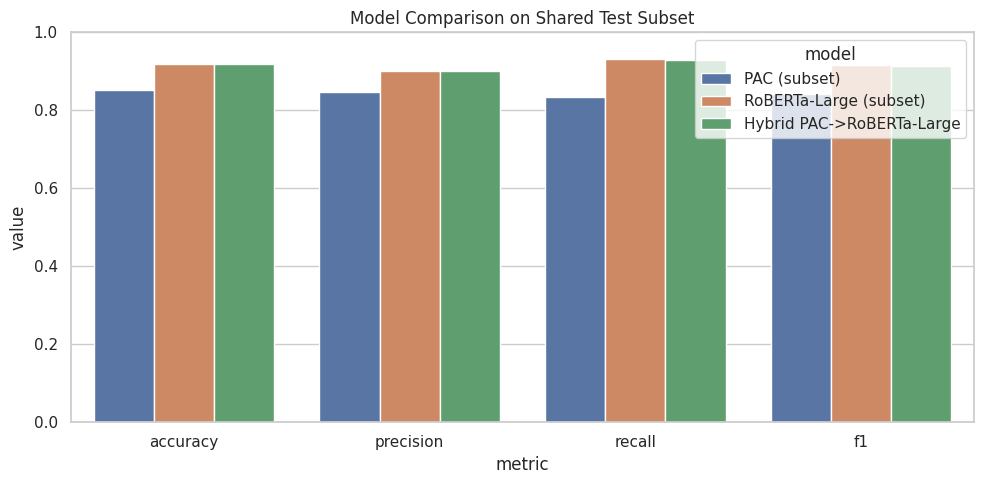

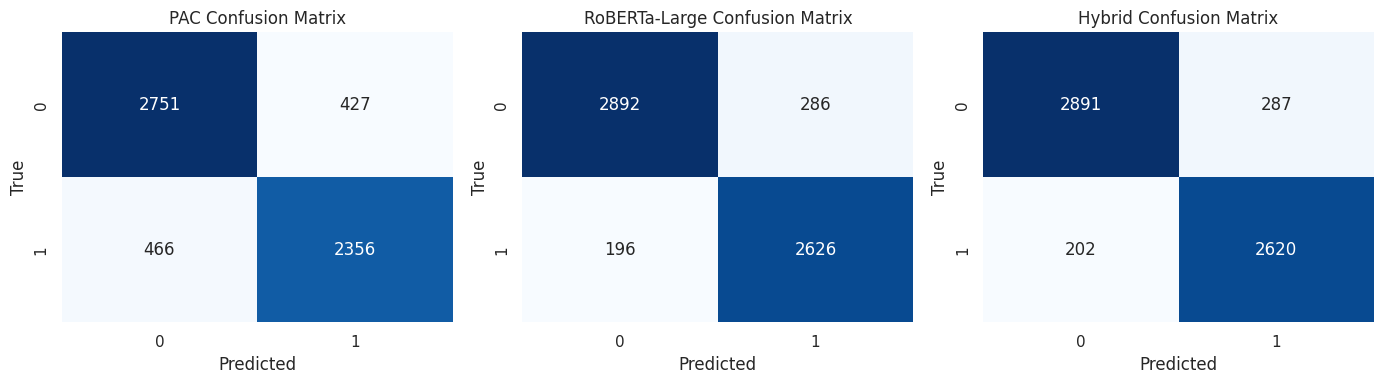

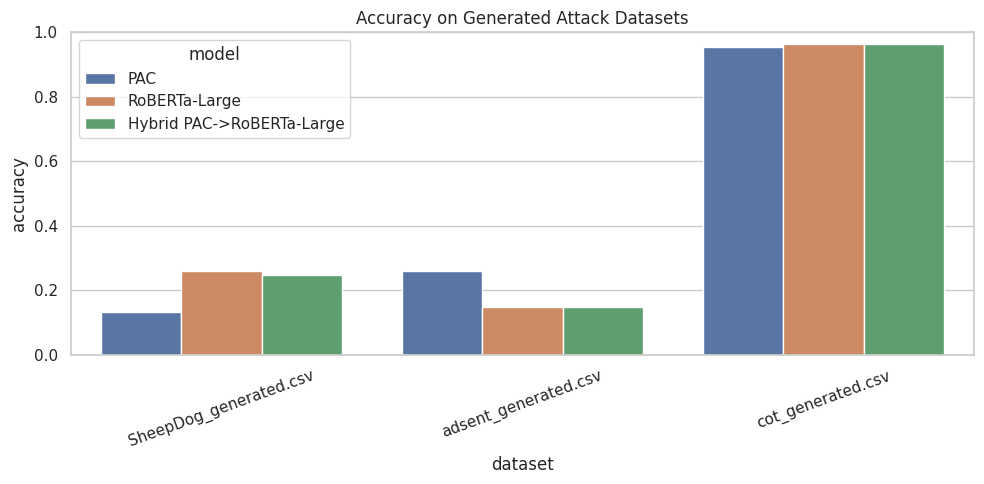

In [19]:
plot_df = base_test_results[base_test_results["model"].isin(["PAC (subset)", "RoBERTa-Large (subset)", "Hybrid PAC->RoBERTa-Large"])].copy()
plot_long = plot_df.melt(id_vars="model", value_vars=["accuracy", "precision", "recall", "f1"], var_name="metric", value_name="value")

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_long, x="metric", y="value", hue="model")
plt.ylim(0, 1)
plt.title("Model Comparison on Shared Test Subset")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
conf_items = [
    ("PAC", y_test_small, pac_test_pred_small),
    ("RoBERTa-Large", y_test_small, roberta_test_pred),
    ("Hybrid", y_test_small, hybrid_test_pred),
]
for ax, (title, yt, yp) in zip(axes, conf_items):
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{title} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

if "generated_eval_results" in globals():
    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=generated_eval_results,
        x="dataset",
        y="accuracy",
        hue="model",
    )
    plt.ylim(0, 1)
    plt.title("Accuracy on Generated Attack Datasets")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()




## ZoFia-Style LLM Method (DeepSeek API)

Implementation goal (lightweight but faithful to the paper):

- Entity-guided retrieval: extract entities -> compute hierarchical salience -> SC-MMR keyword selection -> retrieve external evidence (Wikipedia + web snippets).
- Multi-agent debate: `proponent` vs `skeptic` with a `judge` for final verdict.
- Use this path only for ambiguous samples to control cost.

Set API key before running these cells:

```bash
export DEEPSEEK_API_KEY="your_key_here"
```


In [20]:
import math
import time
import json
import re
import urllib.parse
from typing import Any, Dict, List

import requests
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY", "").strip()
DEEPSEEK_BASE_URL = os.getenv("DEEPSEEK_BASE_URL", "https://api.deepseek.com").rstrip("/")
DEEPSEEK_MODEL = os.getenv("DEEPSEEK_MODEL", "deepseek-chat")

LLM_MAX_DEBATE_ROUNDS = 4
LLM_REQUEST_TIMEOUT = 90
LLM_SLEEP_BETWEEN_CALLS = 0.7
LLM_MAX_CALLS_TEST = 6
LLM_MAX_CALLS_PER_GENERATED_SET = 4
LLM_GENERATED_SAMPLE_PER_SET = 120

# Paper-inspired lightweight settings
NER_LAMBDA_INIT = 0.8
NER_LAMBDA_STEP = 0.1
NER_MIN_ENTITIES = 3
SCMMR_MAX_KEYWORDS = 8
SCMMR_GAMMA = 0.5
OPEN_WEB_MAX_ENTRIES = 10
WIKI_CANDIDATE_LIMIT = 5
CLAIM_SIM_THRESHOLD = 0.1

NEWSY_URL_HINTS = (
    "news",
    "cnn.com",
    "foxnews.com",
    "nytimes.com",
    "bbc.",
    "reuters.com",
    "washingtonpost.com",
    "theguardian.com",
)

print("DeepSeek key found:", bool(DEEPSEEK_API_KEY))
print("DeepSeek base URL:", DEEPSEEK_BASE_URL)
print("DeepSeek model:", DEEPSEEK_MODEL)


DeepSeek key found: True
DeepSeek base URL: https://api.deepseek.com
DeepSeek model: deepseek-chat


In [21]:
def deepseek_chat(messages, model=None, temperature=0.1, max_tokens=700, max_retries=3):
    if not DEEPSEEK_API_KEY:
        raise RuntimeError("DEEPSEEK_API_KEY is empty. Please set it before running LLM cells.")

    model = model or DEEPSEEK_MODEL
    url = f"{DEEPSEEK_BASE_URL}/chat/completions"

    payload = {
        "model": model,
        "messages": messages,
        "temperature": temperature,
        "max_tokens": max_tokens,
        "stream": False,
    }

    headers = {
        "Authorization": f"Bearer {DEEPSEEK_API_KEY}",
        "Content-Type": "application/json",
    }

    last_err = None
    for attempt in range(max_retries):
        try:
            resp = requests.post(url, headers=headers, json=payload, timeout=LLM_REQUEST_TIMEOUT)
            if resp.status_code >= 400:
                raise RuntimeError(f"DeepSeek HTTP {resp.status_code}: {resp.text[:300]}")
            data = resp.json()
            return data["choices"][0]["message"]["content"]
        except Exception as exc:
            last_err = exc
            if attempt < max_retries - 1:
                time.sleep(1.5 * (attempt + 1))
            else:
                raise

    raise last_err


def parse_json_from_text(text):
    text = str(text).strip()
    if not text:
        return None

    try:
        return json.loads(text)
    except Exception:
        pass

    fence_match = re.search(r"```(?:json)?\s*(\{.*?\}|\[.*?\])\s*```", text, flags=re.DOTALL | re.IGNORECASE)
    if fence_match:
        try:
            return json.loads(fence_match.group(1))
        except Exception:
            pass

    for pattern in [r"\{.*\}", r"\[.*\]"]:
        m = re.search(pattern, text, flags=re.DOTALL)
        if m:
            try:
                return json.loads(m.group(0))
            except Exception:
                continue
    return None


def deepseek_json_call(system_prompt, user_prompt, temperature=0.1, max_tokens=700):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    raw = deepseek_chat(messages, temperature=temperature, max_tokens=max_tokens)
    return parse_json_from_text(raw), raw


def clamp01(x):
    try:
        val = float(x)
    except Exception:
        return 0.0
    return max(0.0, min(1.0, val))


def split_sentences(text):
    sents = re.split(r"(?<=[.!?])\s+", str(text))
    sents = [s.strip() for s in sents if s and s.strip()]
    return sents if sents else [clean_text(text)]


def take_first_n_sentences(text, n=3):
    sents = split_sentences(text)
    return " ".join(sents[:n]).strip()


ENTITY_PATTERN = re.compile(
    r"\b(?:[A-Z][a-z]+(?:\s+[A-Z][a-z]+){0,3}|[A-Z]{2,}(?:\s+[A-Z]{2,}){0,2})\b"
)


def _regex_entities(text, max_entities=40):
    candidates = ENTITY_PATTERN.findall(str(text))
    seen = set()
    items = []
    for ent in candidates:
        ent = clean_text(ent)
        if len(ent) < 2:
            continue
        key = ent.lower()
        if key in seen or key in {"the", "this", "that", "news"}:
            continue
        seen.add(key)
        items.append({"entity": ent, "type": "UNK", "confidence": 0.55})
        if len(items) >= max_entities:
            break
    return items


def extract_entities_with_llm(text, max_entities=40):
    if not DEEPSEEK_API_KEY:
        return []

    system_prompt = (
        "You are an NER extractor for fake news detection. "
        "Return strict JSON only with schema: "
        "{\"entities\":[{\"entity\":str,\"type\":str,\"confidence\":float}]}. "
        "Confidence must be in [0,1]."
    )
    user_prompt = (
        f"Extract up to {max_entities} named entities from the news text below. "
        "Focus on people, organizations, locations, events, and products.\n\n"
        f"News text:\n{text}"
    )

    parsed, _ = deepseek_json_call(system_prompt, user_prompt, temperature=0.0, max_tokens=600)
    if parsed is None:
        return []

    if isinstance(parsed, dict):
        entities = parsed.get("entities", [])
    elif isinstance(parsed, list):
        entities = parsed
    else:
        entities = []

    clean_items = []
    seen = set()
    for item in entities:
        if not isinstance(item, dict):
            continue
        ent = clean_text(item.get("entity", ""))
        if not ent:
            continue
        key = ent.lower()
        if key in seen:
            continue
        seen.add(key)
        clean_items.append(
            {
                "entity": ent,
                "type": clean_text(item.get("type", "UNK")) or "UNK",
                "confidence": clamp01(item.get("confidence", 0.5)),
            }
        )

    clean_items.sort(key=lambda x: x.get("confidence", 0.0), reverse=True)
    return clean_items[:max_entities]


def select_entities_by_dynamic_threshold(
    entities,
    lambda_init=NER_LAMBDA_INIT,
    delta=NER_LAMBDA_STEP,
    min_entities=NER_MIN_ENTITIES,
):
    if not entities:
        return [], 0.0

    entities = sorted(entities, key=lambda x: x.get("confidence", 0.0), reverse=True)
    lam = float(lambda_init)
    selected = []

    while lam >= 0.0:
        selected = [e for e in entities if e.get("confidence", 0.0) >= lam]
        if len(selected) >= min_entities:
            break
        lam -= delta

    if not selected:
        selected = entities[: max(1, min_entities)]

    return selected, max(lam, 0.0)


def extract_candidate_entities_with_meta(text, max_entities=40):
    ner_source = "regex"
    raw_entities = []

    if DEEPSEEK_API_KEY:
        try:
            raw_entities = extract_entities_with_llm(text, max_entities=max_entities)
            if raw_entities:
                ner_source = "deepseek-ner"
        except Exception:
            raw_entities = []

    if not raw_entities:
        raw_entities = _regex_entities(text, max_entities=max_entities)

    selected, used_lambda = select_entities_by_dynamic_threshold(raw_entities)

    names = []
    seen = set()
    for e in selected:
        ent = clean_text(e.get("entity", ""))
        if not ent:
            continue
        k = ent.lower()
        if k in seen:
            continue
        seen.add(k)
        names.append(ent)

    return names, {
        "ner_source": ner_source,
        "lambda_used": round(float(used_lambda), 3),
        "raw_entity_count": len(raw_entities),
        "selected_entity_count": len(names),
    }


def extract_candidate_entities(text, max_entities=40):
    names, _ = extract_candidate_entities_with_meta(text, max_entities=max_entities)
    return names


def build_local_contexts(text, entities):
    sents = split_sentences(text)
    lowered = [s.lower() for s in sents]
    contexts = {}

    for ent in entities:
        ent_l = ent.lower()
        hit_idx = None
        for i, s in enumerate(lowered):
            if ent_l in s:
                hit_idx = i
                break

        if hit_idx is None:
            contexts[ent] = sents[0]
        else:
            left = max(0, hit_idx - 1)
            right = min(len(sents), hit_idx + 2)
            contexts[ent] = " ".join(sents[left:right])

    return contexts


def _safe_cosine(v1, v2):
    try:
        return float(cosine_similarity(v1, v2)[0, 0])
    except Exception:
        return 0.0


def compute_hierarchical_salience(text, entities):
    if not entities:
        return {}

    contexts = build_local_contexts(text, entities)
    corpus = [clean_text(text)] + [contexts[e] for e in entities] + entities

    try:
        vec = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)
        X = vec.fit_transform(corpus)
    except Exception:
        return {e: 0.0 for e in entities}

    v_text = X[0]
    v_ctx = X[1 : 1 + len(entities)]
    v_ent = X[1 + len(entities) :]

    salience = {}
    for i, ent in enumerate(entities):
        s_local = _safe_cosine(v_ent[i], v_ctx[i])
        s_global = _safe_cosine(v_ctx[i], v_text)
        salience[ent] = max(0.0, s_local * s_global)
    return salience


def scmmr_select_keywords(
    text,
    candidate_entities=None,
    max_keywords=SCMMR_MAX_KEYWORDS,
    gamma=SCMMR_GAMMA,
):
    entities = list(candidate_entities) if candidate_entities is not None else extract_candidate_entities(text)
    entities = [clean_text(e) for e in entities if clean_text(e)]
    if not entities:
        return []

    salience = compute_hierarchical_salience(text, entities)
    entities = [e for e in entities if e in salience]
    if not entities:
        return []

    if len(entities) == 1:
        return entities

    try:
        vec = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)
        X = vec.fit_transform(entities)
        sim = cosine_similarity(X)
    except Exception:
        return entities[:max_keywords]

    idx_map = {e: i for i, e in enumerate(entities)}

    selected = []
    candidates = entities.copy()

    first = max(candidates, key=lambda e: salience.get(e, 0.0))
    selected.append(first)
    candidates.remove(first)

    mmr_prev = 1.0

    while candidates and len(selected) < max_keywords:
        k = len(selected)
        lam = max(0.1, 1.2 - math.exp(0.2 * k - 0.5) / math.e)

        best_e = None
        best_mmr = -1e9
        for e in candidates:
            ei = idx_map[e]
            max_sim = max(sim[ei, idx_map[s]] for s in selected)
            mmr = lam * salience.get(e, 0.0) - (1.0 - lam) * max_sim
            if mmr > best_mmr:
                best_mmr = mmr
                best_e = e

        if best_e is None:
            break

        if best_mmr <= gamma * mmr_prev:
            break

        selected.append(best_e)
        candidates.remove(best_e)
        mmr_prev = best_mmr

    return selected


def build_open_web_query(keywords):
    keywords = [clean_text(k) for k in keywords if clean_text(k)]
    if not keywords:
        return ""
    core = " AND ".join([f'"{k}"' for k in keywords])
    return f"{core} -site:wikipedia.org -news"


def is_newsy_or_excluded_url(url):
    url_l = str(url).lower()
    if not url_l:
        return False
    if "wikipedia.org" in url_l:
        return True
    return any(hint in url_l for hint in NEWSY_URL_HINTS)


def _walk_ddg_topics(items):
    for item in items:
        if isinstance(item, dict):
            if "Text" in item:
                yield item
            if "Topics" in item and isinstance(item["Topics"], list):
                for sub in _walk_ddg_topics(item["Topics"]):
                    yield sub


def fetch_ddg_snippets(query, timeout=20, max_items=OPEN_WEB_MAX_ENTRIES):
    if not clean_text(query):
        return []

    snippets = []
    seen = set()

    try:
        resp = requests.get(
            "https://api.duckduckgo.com/",
            params={"q": query, "format": "json", "no_redirect": 1, "no_html": 1},
            timeout=timeout,
        )
        data = resp.json()
    except Exception:
        return []

    first_url = data.get("AbstractURL", "")
    first_snippet = clean_text(data.get("AbstractText", ""))
    if first_snippet and not is_newsy_or_excluded_url(first_url):
        snippets.append(
            {
                "source": "open_web",
                "title": clean_text(data.get("Heading", "Open web")) or "Open web",
                "snippet": first_snippet[:700],
                "url": first_url,
            }
        )
        seen.add(first_snippet[:220].lower())

    for t in _walk_ddg_topics(data.get("RelatedTopics", [])):
        snip = clean_text(t.get("Text", ""))
        url = t.get("FirstURL", "")
        if not snip or is_newsy_or_excluded_url(url):
            continue
        sig = snip[:220].lower()
        if sig in seen:
            continue
        snippets.append(
            {
                "source": "open_web",
                "title": "Open web",
                "snippet": snip[:500],
                "url": url,
            }
        )
        seen.add(sig)
        if len(snippets) >= max_items:
            break

    return snippets[:max_items]


def fetch_wikipedia_candidates(query, timeout=20, limit=WIKI_CANDIDATE_LIMIT):
    try:
        resp = requests.get(
            "https://en.wikipedia.org/w/api.php",
            params={
                "action": "query",
                "list": "search",
                "srsearch": query,
                "format": "json",
                "utf8": 1,
                "srlimit": limit,
            },
            timeout=timeout,
        )
        data = resp.json()
        return data.get("query", {}).get("search", [])
    except Exception:
        return []


def fetch_wikipedia_summary_by_title(title, timeout=20):
    try:
        title_enc = urllib.parse.quote(str(title).replace(" ", "_"))
        resp = requests.get(
            f"https://en.wikipedia.org/api/rest_v1/page/summary/{title_enc}",
            timeout=timeout,
        )
        data = resp.json()
        extract = clean_text(data.get("extract", ""))
        if not extract:
            return None
        return {
            "title": clean_text(data.get("title", title)) or clean_text(title),
            "snippet": take_first_n_sentences(extract, n=3),
            "url": data.get("content_urls", {}).get("desktop", {}).get("page", ""),
        }
    except Exception:
        return None


def _context_similarity(a, b):
    a = clean_text(a)
    b = clean_text(b)
    if not a or not b:
        return 0.0
    try:
        vec = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)
        X = vec.fit_transform([a, b])
        return _safe_cosine(X[0], X[1])
    except Exception:
        return 0.0


def choose_wikipedia_entry(keyword, local_context, timeout=20):
    candidates = fetch_wikipedia_candidates(keyword, timeout=timeout, limit=WIKI_CANDIDATE_LIMIT)
    if not candidates:
        return None

    best_item = None
    best_score = -1.0

    for cand in candidates:
        title = cand.get("title", "")
        if not title:
            continue

        summary = fetch_wikipedia_summary_by_title(title, timeout=timeout)
        if summary is None:
            continue

        cand_text = clean_text(cand.get("snippet", ""))
        joined = f"{summary['title']} {summary['snippet']} {cand_text}"
        score = _context_similarity(local_context, joined)
        if score > best_score:
            best_score = score
            best_item = {
                "source": "wikipedia",
                "title": summary["title"],
                "snippet": summary["snippet"],
                "url": summary["url"],
                "context_match": round(float(score), 4),
            }

    return best_item


def build_evidence_pool(text, max_items=12):
    entities, ner_meta = extract_candidate_entities_with_meta(text, max_entities=40)
    contexts = build_local_contexts(text, entities) if entities else {}
    salience = compute_hierarchical_salience(text, entities) if entities else {}

    keywords = scmmr_select_keywords(
        text,
        candidate_entities=entities,
        max_keywords=SCMMR_MAX_KEYWORDS,
        gamma=SCMMR_GAMMA,
    )

    if not keywords:
        keywords = entities[: min(4, len(entities))]
    if not keywords:
        keywords = [w for w in clean_text(text).split()[:4] if w]

    open_web_query = build_open_web_query(keywords)
    open_web_items = fetch_ddg_snippets(open_web_query, max_items=OPEN_WEB_MAX_ENTRIES)

    wikipedia_items = []
    for kw in keywords[:SCMMR_MAX_KEYWORDS]:
        wk = choose_wikipedia_entry(kw, contexts.get(kw, ""))
        if wk is not None:
            wikipedia_items.append(wk)

    merged_evidence = []
    seen = set()
    max_len = max(len(wikipedia_items), len(open_web_items))
    for i in range(max_len):
        for src in (wikipedia_items, open_web_items):
            if i >= len(src):
                continue
            item = src[i]
            sn = clean_text(item.get("snippet", ""))
            if not sn:
                continue
            key = sn[:260].lower()
            if key in seen:
                continue
            seen.add(key)
            merged_evidence.append(item)
            if len(merged_evidence) >= max_items:
                break
        if len(merged_evidence) >= max_items:
            break

    return {
        "keywords": keywords,
        "entities": entities,
        "salience": {k: round(float(v), 6) for k, v in salience.items()},
        "contexts": contexts,
        "evidence": merged_evidence,
        "open_web": open_web_items,
        "wikipedia": wikipedia_items,
        "open_web_query": open_web_query,
        "ner_meta": ner_meta,
    }


def format_evidence_for_prompt(evidence_pool, max_chars=3500):
    lines = []

    kw = evidence_pool.get("keywords", [])
    if kw:
        lines.append("Keywords: " + ", ".join(kw))

    wiki_items = evidence_pool.get("wikipedia", [])
    if wiki_items:
        lines.append("\n[Wikipedia]")
        for i, item in enumerate(wiki_items, start=1):
            lines.append(
                f"W{i}. title={item.get('title','')} | snippet={clean_text(item.get('snippet',''))} | url={item.get('url','')}"
            )

    web_items = evidence_pool.get("open_web", [])
    if web_items:
        lines.append("\n[Open Web]")
        for i, item in enumerate(web_items, start=1):
            lines.append(
                f"O{i}. title={item.get('title','')} | snippet={clean_text(item.get('snippet',''))} | url={item.get('url','')}"
            )

    text = "\n".join(lines).strip()
    if len(text) > max_chars:
        text = text[:max_chars]
    if not text:
        text = "No external evidence found."
    return text


def run_linguist_agent(text):
    system_prompt = (
        "You are the Linguist agent for fake news detection. "
        "Analyze in five dimensions independently: Sentence, Word, Grammar, Emotion, Information Quality. "
        "Return strict JSON only."
    )
    user_prompt = (
        "Output JSON schema: "
        "{\"overall\":\"real|fake|mixed\","
        "\"dimensions\":[{\"name\":str,\"stance\":\"real|fake|uncertain\",\"reason\":str}],"
        "\"summary\":str}.\n\n"
        f"News text:\n{text}"
    )

    parsed, raw = deepseek_json_call(system_prompt, user_prompt, temperature=0.1, max_tokens=800)
    if isinstance(parsed, dict):
        return parsed
    return {"overall": "mixed", "dimensions": [], "summary": clean_text(raw)[:400]}


def run_domain_expert_agent(text, wikipedia_items):
    wiki_block = "\n".join(
        f"- {item.get('title','')}: {clean_text(item.get('snippet',''))}" for item in wikipedia_items[:6]
    )

    system_prompt = (
        "You are the Domain-Specific Expert agent for fake news detection. "
        "Infer a suitable expert role first, then assess Knowledge Concordance and Logical Integrity. "
        "Return strict JSON only."
    )
    user_prompt = (
        "Output JSON schema: "
        "{\"expert_role\":str,\"stance\":\"real|fake|uncertain\","
        "\"knowledge_concordance\":str,\"logical_integrity\":str,\"summary\":str}.\n\n"
        f"News text:\n{text}\n\n"
        f"Wikipedia evidence:\n{wiki_block if wiki_block else 'N/A'}"
    )

    parsed, raw = deepseek_json_call(system_prompt, user_prompt, temperature=0.1, max_tokens=700)
    if isinstance(parsed, dict):
        return parsed
    return {
        "expert_role": "general analyst",
        "stance": "uncertain",
        "knowledge_concordance": "",
        "logical_integrity": "",
        "summary": clean_text(raw)[:400],
    }


def extract_claims_agent(text, max_subclaims=4):
    system_prompt = (
        "You are Claim Extractor. Convert the news text into one core claim and several objective subclaims. "
        "Return strict JSON only."
    )
    user_prompt = (
        "Output JSON schema: {\"core_claim\":str,\"subclaims\":[str,...]}. "
        f"Limit subclaims to <= {max_subclaims}.\n\n"
        f"News text:\n{text}"
    )

    parsed, raw = deepseek_json_call(system_prompt, user_prompt, temperature=0.0, max_tokens=500)
    if isinstance(parsed, dict):
        core = clean_text(parsed.get("core_claim", ""))
        subs = parsed.get("subclaims", [])
        if not isinstance(subs, list):
            subs = []
        subs = [clean_text(s) for s in subs if clean_text(s)]
        if not core:
            core = split_sentences(text)[0]
        return {"core_claim": core, "subclaims": subs[:max_subclaims]}

    fallback_core = split_sentences(text)[0]
    return {"core_claim": fallback_core, "subclaims": []}


def build_claim_relevant_context(claim, open_web_items, top_k=5, sim_threshold=CLAIM_SIM_THRESHOLD):
    chunks = []
    for item in open_web_items:
        snip = clean_text(item.get("snippet", ""))
        if not snip:
            continue
        chunks.append(
            {
                "title": clean_text(item.get("title", "")),
                "snippet": snip,
                "url": clean_text(item.get("url", "")),
            }
        )

    if not chunks:
        return []

    corpus = [clean_text(claim)] + [c["snippet"] for c in chunks]
    try:
        vec = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=1)
        X = vec.fit_transform(corpus)
        sims = cosine_similarity(X[0], X[1:])[0]
    except Exception:
        sims = np.zeros(len(chunks))

    ranked = np.argsort(-sims)
    selected = []
    for i in ranked:
        score = float(sims[i])
        if score < sim_threshold and len(selected) >= 2:
            continue
        selected.append({**chunks[i], "similarity": round(score, 4)})
        if len(selected) >= top_k:
            break

    return selected


def verify_claim_agent(claim, rel_context):
    if not rel_context:
        return {
            "label": "Not Enough Information",
            "reasoning": "No relevant open-web context.",
            "evidence_quotes": [],
        }

    context_block = "\n".join(
        f"[{i+1}] sim={c.get('similarity',0)} | {c['snippet']}" for i, c in enumerate(rel_context)
    )

    system_prompt = (
        "You are Claim Verifier. Use only provided context to judge claim. "
        "Return strict JSON only."
    )
    user_prompt = (
        "Output JSON schema: "
        "{\"label\":\"Supports|Refutes|Not Enough Information\","
        "\"reasoning\":str,\"evidence_quotes\":[str,...]}.\n\n"
        f"Claim:\n{claim}\n\n"
        f"Relevant context:\n{context_block}"
    )

    parsed, raw = deepseek_json_call(system_prompt, user_prompt, temperature=0.0, max_tokens=500)
    if isinstance(parsed, dict):
        label = clean_text(parsed.get("label", "Not Enough Information"))
        if label not in {"Supports", "Refutes", "Not Enough Information"}:
            label = "Not Enough Information"
        quotes = parsed.get("evidence_quotes", [])
        if not isinstance(quotes, list):
            quotes = []
        quotes = [clean_text(q) for q in quotes if clean_text(q)][:3]
        return {
            "label": label,
            "reasoning": clean_text(parsed.get("reasoning", ""))[:300],
            "evidence_quotes": quotes,
        }

    return {
        "label": "Not Enough Information",
        "reasoning": clean_text(raw)[:300],
        "evidence_quotes": [],
    }


def run_claim_verification_pipeline(text, open_web_items):
    claims = extract_claims_agent(text)
    all_claims = [claims.get("core_claim", "")] + claims.get("subclaims", [])
    all_claims = [c for c in all_claims if clean_text(c)]

    results = []
    for claim in all_claims[:5]:
        rel_ctx = build_claim_relevant_context(claim, open_web_items, top_k=5, sim_threshold=CLAIM_SIM_THRESHOLD)
        ver = verify_claim_agent(claim, rel_ctx)
        results.append(
            {
                "claim": claim,
                "label": ver["label"],
                "reasoning": ver["reasoning"],
                "evidence_quotes": ver["evidence_quotes"],
                "n_context": len(rel_ctx),
            }
        )

    label_count = {"Supports": 0, "Refutes": 0, "Not Enough Information": 0}
    for r in results:
        label_count[r["label"]] = label_count.get(r["label"], 0) + 1

    if label_count["Supports"] > label_count["Refutes"]:
        summary = "mostly_supports"
    elif label_count["Refutes"] > label_count["Supports"]:
        summary = "mostly_refutes"
    else:
        summary = "mixed_or_insufficient"

    return {
        "core_claim": claims.get("core_claim", ""),
        "subclaims": claims.get("subclaims", []),
        "verifications": results,
        "summary": summary,
        "label_count": label_count,
    }


def run_llm_collaboration(text, evidence_pool):
    if not DEEPSEEK_API_KEY:
        return {}

    collab = {}

    try:
        collab["linguist"] = run_linguist_agent(text)
    except Exception as exc:
        collab["linguist"] = {"overall": "mixed", "summary": f"linguist_error: {exc}"}

    try:
        collab["expert"] = run_domain_expert_agent(text, evidence_pool.get("wikipedia", []))
    except Exception as exc:
        collab["expert"] = {"stance": "uncertain", "summary": f"expert_error: {exc}"}

    try:
        collab["claim_verification"] = run_claim_verification_pipeline(text, evidence_pool.get("open_web", []))
    except Exception as exc:
        collab["claim_verification"] = {
            "summary": "mixed_or_insufficient",
            "label_count": {},
            "error": str(exc),
        }

    return collab


def format_collaboration_for_prompt(collab, max_chars=2200):
    if not collab:
        return "No collaboration analysis available."

    lines = []

    ling = collab.get("linguist", {})
    if isinstance(ling, dict):
        lines.append(f"Linguist overall: {ling.get('overall', 'mixed')}")
        for item in ling.get("dimensions", [])[:5]:
            if isinstance(item, dict):
                lines.append(
                    f"- {item.get('name','')}: {item.get('stance','uncertain')} | {clean_text(item.get('reason',''))}"
                )

    expert = collab.get("expert", {})
    if isinstance(expert, dict):
        lines.append(
            f"Expert ({expert.get('expert_role','general analyst')}): stance={expert.get('stance','uncertain')} | "
            f"summary={clean_text(expert.get('summary',''))}"
        )

    claim_v = collab.get("claim_verification", {})
    if isinstance(claim_v, dict):
        lines.append(f"Claim verification summary: {claim_v.get('summary', 'mixed_or_insufficient')}")
        lc = claim_v.get("label_count", {})
        if isinstance(lc, dict):
            lines.append(f"Claim labels: {lc}")
        for r in claim_v.get("verifications", [])[:3]:
            lines.append(f"- Claim: {clean_text(r.get('claim',''))} | label={r.get('label','Not Enough Information')}")

    text = "\n".join(lines).strip()
    if len(text) > max_chars:
        text = text[:max_chars]
    return text if text else "No collaboration analysis available."


In [22]:
def run_zofia_debate(claim_text, evidence_pool, collaboration, max_rounds=LLM_MAX_DEBATE_ROUNDS):
    evidence_block = format_evidence_for_prompt(evidence_pool)
    collab_block = format_collaboration_for_prompt(collaboration)

    history = []
    last_skeptic = ""
    judge_result = {
        "verdict": "insufficient",
        "confidence": 0.0,
        "reasoning": "No decision",
        "need_more_rounds": True,
        "key_evidence": [],
    }

    for r in range(1, max_rounds + 1):
        pro_messages = [
            {
                "role": "system",
                "content": (
                    "You are PROPONENT agent. Argue the news is REAL. "
                    "First rebut skeptic's previous point, then provide 3 concise evidence-backed arguments. "
                    "Use only supplied material."
                ),
            },
            {
                "role": "user",
                "content": (
                    f"Claim text:\n{claim_text}\n\n"
                    f"External evidence:\n{evidence_block}\n\n"
                    f"Collaboration analysis:\n{collab_block}\n\n"
                    f"Skeptic previous argument:\n{last_skeptic if last_skeptic else 'N/A'}"
                ),
            },
        ]
        pro_arg = deepseek_chat(pro_messages, temperature=0.1, max_tokens=450)

        con_messages = [
            {
                "role": "system",
                "content": (
                    "You are SKEPTIC agent. Argue the news is FAKE. "
                    "First rebut proponent's point, then provide 3 concise evidence-backed arguments. "
                    "Use only supplied material."
                ),
            },
            {
                "role": "user",
                "content": (
                    f"Claim text:\n{claim_text}\n\n"
                    f"External evidence:\n{evidence_block}\n\n"
                    f"Collaboration analysis:\n{collab_block}\n\n"
                    f"Proponent argument:\n{pro_arg}"
                ),
            },
        ]
        con_arg = deepseek_chat(con_messages, temperature=0.1, max_tokens=450)

        history.append({"round": r, "proponent": clean_text(pro_arg), "skeptic": clean_text(con_arg)})

        judge_messages = [
            {
                "role": "system",
                "content": (
                    "You are JUDGE agent. Assess debate history and output strict JSON only. "
                    "Fields: verdict(real|fake|insufficient), confidence(0-1), need_more_rounds(boolean), "
                    "reasoning(short), key_evidence(list)."
                ),
            },
            {
                "role": "user",
                "content": (
                    f"Claim text:\n{claim_text}\n\n"
                    f"External evidence:\n{evidence_block}\n\n"
                    f"Collaboration analysis:\n{collab_block}\n\n"
                    f"Debate history:\n{json.dumps(history, ensure_ascii=False)}"
                ),
            },
        ]

        judge_raw = deepseek_chat(judge_messages, temperature=0.0, max_tokens=350)
        parsed = parse_json_from_text(judge_raw)

        if not isinstance(parsed, dict):
            parsed = {
                "verdict": "insufficient",
                "confidence": 0.0,
                "need_more_rounds": True,
                "reasoning": clean_text(judge_raw)[:400],
                "key_evidence": [],
            }

        parsed["verdict"] = str(parsed.get("verdict", "insufficient")).lower()
        parsed["confidence"] = clamp01(parsed.get("confidence", 0.0))
        parsed["need_more_rounds"] = bool(parsed.get("need_more_rounds", parsed["verdict"] == "insufficient"))
        if not isinstance(parsed.get("key_evidence", []), list):
            parsed["key_evidence"] = []

        judge_result = parsed

        if judge_result["verdict"] in {"real", "fake"} and not judge_result["need_more_rounds"]:
            break

        last_skeptic = con_arg

    return judge_result, history


def zofia_predict_single(text):
    text = clean_text(text)
    evidence_pool = build_evidence_pool(text)
    collaboration = run_llm_collaboration(text, evidence_pool)
    judge_result, debate_history = run_zofia_debate(text, evidence_pool, collaboration)

    verdict = str(judge_result.get("verdict", "insufficient")).lower()
    if verdict == "real":
        label = 1
    elif verdict == "fake":
        label = 0
    else:
        label = None

    conf = clamp01(judge_result.get("confidence", 0.0))

    claim_v = collaboration.get("claim_verification", {}) if isinstance(collaboration, dict) else {}
    n_verified_claims = len(claim_v.get("verifications", [])) if isinstance(claim_v, dict) else 0

    trace = {
        "verdict": verdict,
        "confidence": conf,
        "reasoning": clean_text(str(judge_result.get("reasoning", "")))[:500],
        "keywords": evidence_pool.get("keywords", []),
        "evidence_count": len(evidence_pool.get("evidence", [])),
        "open_web_count": len(evidence_pool.get("open_web", [])),
        "wikipedia_count": len(evidence_pool.get("wikipedia", [])),
        "debate_rounds": len(debate_history),
        "ner_source": evidence_pool.get("ner_meta", {}).get("ner_source", "unknown"),
        "ner_lambda": evidence_pool.get("ner_meta", {}).get("lambda_used", 0.0),
        "claims_verified": n_verified_claims,
    }
    return label, trace


In [23]:
import tqdm


def softmax_np(logits):
    logits = np.asarray(logits)
    logits = logits - logits.max(axis=1, keepdims=True)
    expv = np.exp(logits)
    return expv / expv.sum(axis=1, keepdims=True)


roberta_val_conf = softmax_np(val_out.predictions).max(axis=1)
roberta_test_conf = softmax_np(test_out.predictions).max(axis=1)

PAC_AMBIG_THRESHOLD = float(np.quantile(np.abs(pac_val_scores_small), 0.30))
ROBERTA_AMBIG_THRESHOLD = float(np.quantile(roberta_val_conf, 0.30))

model_disagree_test = pac_test_pred_small != roberta_test_pred

ambiguous_mask_test = (
    (np.abs(pac_test_scores_small) < PAC_AMBIG_THRESHOLD)
    | (roberta_test_conf < ROBERTA_AMBIG_THRESHOLD)
    | model_disagree_test
)

print("PAC ambiguity threshold:", round(PAC_AMBIG_THRESHOLD, 6))
print("RoBERTa-Large ambiguity threshold:", round(ROBERTA_AMBIG_THRESHOLD, 6))
print("Disagreement ratio on test subset:", round(float(model_disagree_test.mean()), 4))
print("Ambiguous ratio on test subset:", round(float(ambiguous_mask_test.mean()), 4))

llm_hybrid_test_pred = hybrid_test_pred.copy()
llm_trace_records = []
llm_called_mask = np.zeros(len(y_test_small), dtype=bool)

if not DEEPSEEK_API_KEY:
    print("DEEPSEEK_API_KEY is missing, skip LLM inference. Existing models remain available.")
    zofia_test_metrics = None
else:
    candidate_idx = np.where(ambiguous_mask_test)[0]

    if len(candidate_idx):
        pac_unc = 1.0 - np.clip(
            np.abs(pac_test_scores_small) / (np.max(np.abs(pac_val_scores_small)) + 1e-9),
            0.0,
            1.0,
        )
        roberta_unc = 1.0 - roberta_test_conf
        uncertainty = pac_unc + roberta_unc + 0.5 * model_disagree_test.astype(float)
        candidate_idx = candidate_idx[np.argsort(-uncertainty[candidate_idx])]

    if LLM_MAX_CALLS_TEST is not None and len(candidate_idx) > LLM_MAX_CALLS_TEST:
        candidate_idx = candidate_idx[:LLM_MAX_CALLS_TEST]

    print(f"Running ZoFia-LLM on {len(candidate_idx)} ambiguous test samples...")

    for idx in tqdm.tqdm(candidate_idx, desc="ZoFia test inference"):
        pred_label, trace = zofia_predict_single(roberta_test_df.iloc[idx]["text"])
        if pred_label is not None:
            llm_hybrid_test_pred[idx] = int(pred_label)
        llm_called_mask[idx] = True

        llm_trace_records.append(
            {
                "idx": int(idx),
                "true_label": int(y_test_small[idx]),
                "base_hybrid_pred": int(hybrid_test_pred[idx]),
                "llm_hybrid_pred": int(llm_hybrid_test_pred[idx]),
                "pac_score": float(pac_test_scores_small[idx]),
                "roberta_conf": float(roberta_test_conf[idx]),
                "pac_roberta_disagree": bool(model_disagree_test[idx]),
                **trace,
            }
        )
        time.sleep(LLM_SLEEP_BETWEEN_CALLS)

    zofia_test_metrics = binary_metrics(y_test_small, llm_hybrid_test_pred)
    print_metrics("Hybrid + ZoFia(LLM) test", zofia_test_metrics)


comparison_with_llm = comparison.copy()
if zofia_test_metrics is not None:
    comparison_with_llm = pd.concat(
        [
            comparison_with_llm,
            pd.DataFrame([{"model": "Hybrid + ZoFia(LLM)", **zofia_test_metrics}]),
        ],
        ignore_index=True,
    )

comparison_with_llm


PAC ambiguity threshold: 0.888801
RoBERTa-Large ambiguity threshold: 0.982322
Disagreement ratio on test subset: 0.1425
Ambiguous ratio on test subset: 0.4407
Running ZoFia-LLM on 6 ambiguous test samples...


ZoFia test inference: 100%|█████████████████████████████████████████████████████| 6/6 [12:23<00:00, 123.86s/it]

Hybrid + ZoFia(LLM) test
  accuracy: 0.9183
  precision: 0.9012
  recall: 0.9281
  f1: 0.9145


,model,accuracy,precision,recall,f1
0,PAC (subset),0.851167,0.846568,0.834869,0.840678
1,RoBERTa-Large,0.919667,0.901786,0.930546,0.915940
2,Hybrid PAC->RoBERTa-Large,0.918500,0.901273,0.928420,0.914645
3,Hybrid + ZoFia(LLM),0.918333,0.901239,0.928065,0.914455


In [24]:
def evaluate_generated_with_llm(sample_per_set=LLM_GENERATED_SAMPLE_PER_SET):
    if not DEEPSEEK_API_KEY:
        print("DEEPSEEK_API_KEY missing. Skip generated-set LLM evaluation.")
        return pd.DataFrame()

    gdir = resolve_generated_dir()
    rows = []

    for csv_path in sorted(gdir.glob("*.csv")):
        raw_df = pd.read_csv(csv_path)
        eval_df = attach_ground_truth(raw_df)

        if sample_per_set is not None and len(eval_df) > sample_per_set:
            eval_df = stratified_downsample(eval_df, sample_per_set, seed=SEED)

        y_true = eval_df["label"].to_numpy()
        texts = eval_df["text"].tolist()

        X = tfidf.transform(texts)
        pac_scores = pac.decision_function(X)
        pac_pred = (pac_scores >= 0).astype(int)

        roberta_pred = roberta_predict_texts(texts)
        roberta_conf = softmax_np(
            trainer.predict(
                Dataset.from_dict({"text": texts})
                .map(tokenize_batch, batched=True, remove_columns=["text"])
                .with_format(type="torch", columns=["input_ids", "attention_mask"])
            ).predictions
        ).max(axis=1)

        hybrid_pred = np.where(np.abs(pac_scores) >= best_threshold, pac_pred, roberta_pred)
        disagree_mask = pac_pred != roberta_pred

        ambiguous_mask = (
            (np.abs(pac_scores) < PAC_AMBIG_THRESHOLD)
            | (roberta_conf < ROBERTA_AMBIG_THRESHOLD)
            | disagree_mask
        )

        llm_pred = hybrid_pred.copy()
        amb_idx = np.where(ambiguous_mask)[0]

        if len(amb_idx):
            pac_unc = 1.0 - np.clip(
                np.abs(pac_scores) / (np.max(np.abs(pac_scores)) + 1e-9),
                0.0,
                1.0,
            )
            roberta_unc = 1.0 - roberta_conf
            uncertainty = pac_unc + roberta_unc + 0.5 * disagree_mask.astype(float)
            amb_idx = amb_idx[np.argsort(-uncertainty[amb_idx])]

        if LLM_MAX_CALLS_PER_GENERATED_SET is not None and len(amb_idx) > LLM_MAX_CALLS_PER_GENERATED_SET:
            amb_idx = amb_idx[:LLM_MAX_CALLS_PER_GENERATED_SET]

        print(
            f"{csv_path.name}: total={len(eval_df)}, ambiguous={int(ambiguous_mask.sum())}, "
            f"llm_calls={len(amb_idx)}"
        )

        for idx in tqdm.tqdm(amb_idx, desc=f"LLM {csv_path.name}"):
            pred_label, _ = zofia_predict_single(texts[idx])
            if pred_label is not None:
                llm_pred[idx] = int(pred_label)
            time.sleep(LLM_SLEEP_BETWEEN_CALLS)

        metrics = binary_metrics(y_true, llm_pred)
        rows.append(
            {
                "dataset": csv_path.name,
                "model": "Hybrid + ZoFia(LLM)",
                "n_eval": len(eval_df),
                "n_ambiguous": int(ambiguous_mask.sum()),
                "n_llm_calls": len(amb_idx),
                **metrics,
            }
        )

    return pd.DataFrame(rows)


generated_llm_results = evaluate_generated_with_llm()
if not generated_llm_results.empty:
    generated_eval_results_all = pd.concat(
        [generated_eval_results, generated_llm_results[["dataset", "model", "accuracy", "precision", "recall", "f1"]]],
        ignore_index=True,
    )
else:
    generated_eval_results_all = generated_eval_results.copy()

generated_eval_results_all


Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

SheepDog_generated.csv: total=120, ambiguous=86, llm_calls=4


LLM SheepDog_generated.csv: 100%|███████████████████████████████████████████████| 4/4 [08:58<00:00, 134.71s/it]


Map:   0%|          | 0/120 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

cot_generated.csv: total=120, ambiguous=70, llm_calls=4


LLM cot_generated.csv: 100%|████████████████████████████████████████████████████| 4/4 [09:36<00:00, 144.24s/it]


,dataset,model,accuracy,precision,recall,f1
0,SheepDog_generated.csv,PAC,0.132716,0.153846,0.172996,0.162860
1,SheepDog_generated.csv,RoBERTa-Large,0.260288,0.198276,0.169831,0.182955
2,SheepDog_generated.csv,Hybrid PAC->RoBERTa-Large,0.247942,0.183498,0.157173,0.169318
3,adsent_generated.csv,PAC,0.260000,1.000000,0.260000,0.412698
4,adsent_generated.csv,RoBERTa-Large,0.147000,1.000000,0.147000,0.256321
5,adsent_generated.csv,Hybrid PAC->RoBERTa-Large,0.147000,1.000000,0.147000,0.256321
6,cot_generated.csv,PAC,0.953846,1.000000,0.953846,0.976378
7,cot_generated.csv,RoBERTa-Large,0.964103,1.000000,0.964103,0.981723
8,cot_generated.csv,Hybrid PAC->RoBERTa-Large,0.964103,1.000000,0.964103,0.981723
9,SheepDog_generated.csv,Hybrid + ZoFia(LLM),0.208333,0.166667,0.152542,0.159292


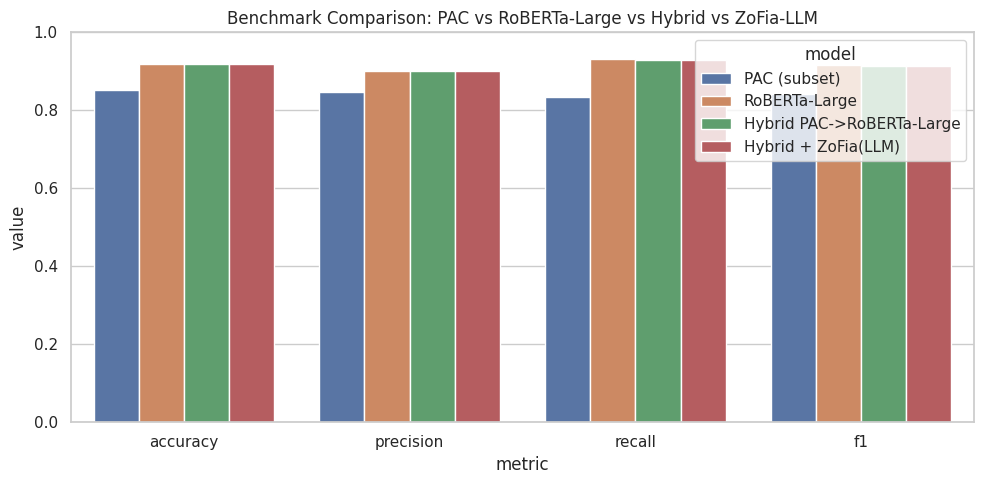

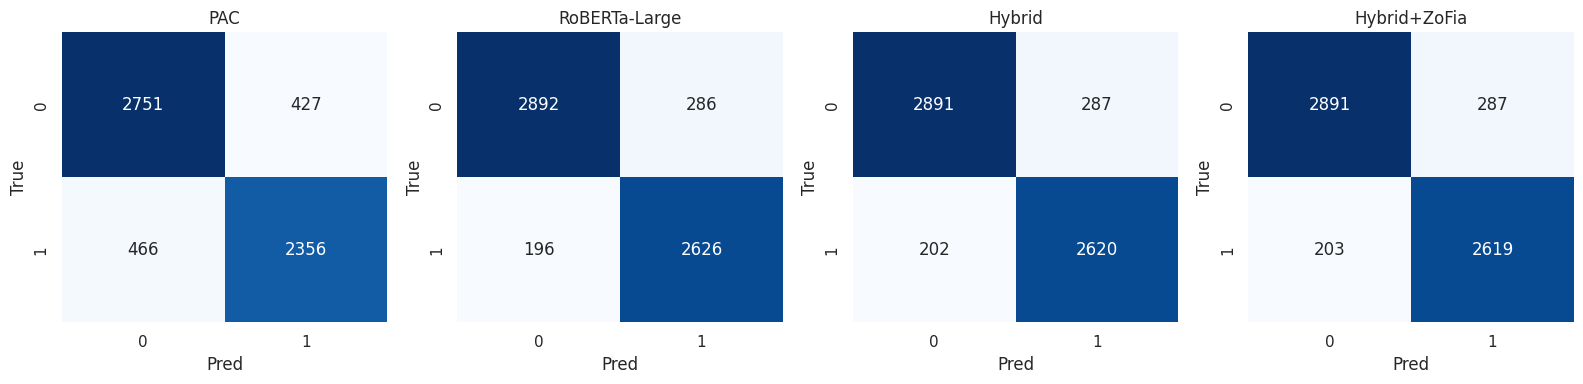

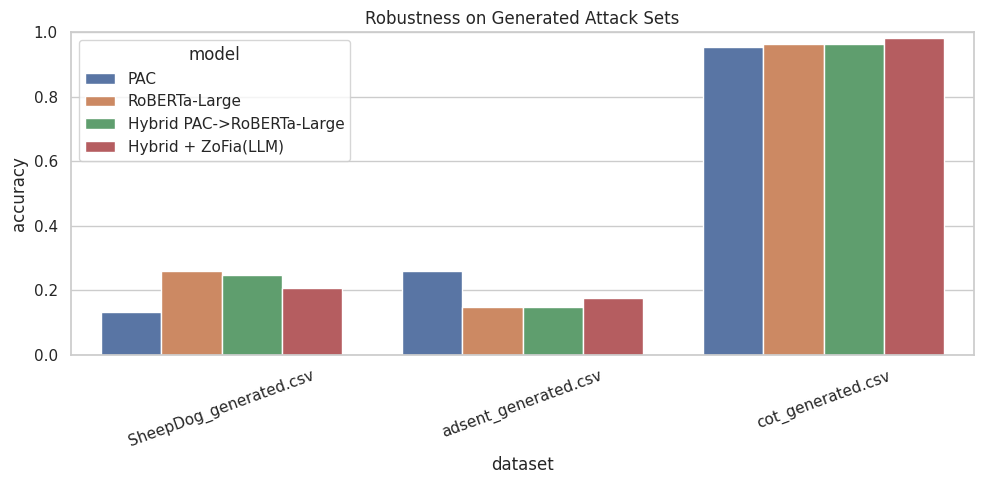

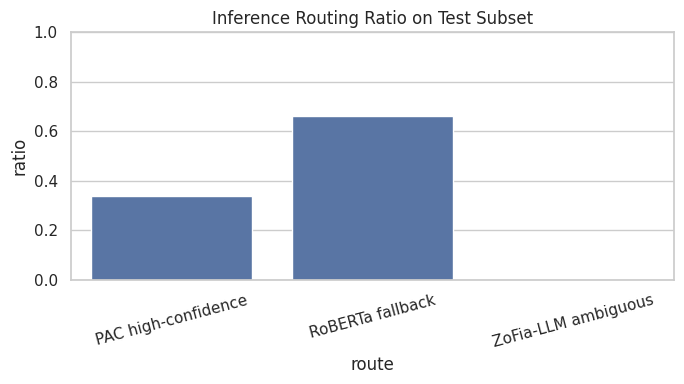

,model,accuracy,precision,recall,f1
0,PAC (subset),0.851167,0.846568,0.834869,0.840678
1,RoBERTa-Large,0.919667,0.901786,0.930546,0.915940
2,Hybrid PAC->RoBERTa-Large,0.918500,0.901273,0.928420,0.914645
3,Hybrid + ZoFia(LLM),0.918333,0.901239,0.928065,0.914455


In [25]:
fig_dir = ARTIFACT_DIR / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# 1) Main benchmark metrics including ZoFia-LLM (if available)
bench_plot_df = comparison_with_llm.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=bench_plot_df, x="metric", y="value", hue="model")
plt.ylim(0, 1)
plt.title("Benchmark Comparison: PAC vs RoBERTa-Large vs Hybrid vs ZoFia-LLM")
plt.tight_layout()
plt.savefig(fig_dir / "benchmark_metrics_with_llm.png", dpi=180)
plt.show()

# 2) Confusion matrices including ZoFia-LLM when available
cm_items = [
    ("PAC", y_test_small, pac_test_pred_small),
    ("RoBERTa-Large", y_test_small, roberta_test_pred),
    ("Hybrid", y_test_small, hybrid_test_pred),
]
if zofia_test_metrics is not None:
    cm_items.append(("Hybrid+ZoFia", y_test_small, llm_hybrid_test_pred))

fig, axes = plt.subplots(1, len(cm_items), figsize=(4 * len(cm_items), 4))
if len(cm_items) == 1:
    axes = [axes]
for ax, (name, yt, yp) in zip(axes, cm_items):
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Pred")
    ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(fig_dir / "confusion_matrices_with_llm.png", dpi=180)
plt.show()

# 3) Generated-set robustness chart
plt.figure(figsize=(10, 5))
sns.barplot(
    data=generated_eval_results_all,
    x="dataset",
    y="accuracy",
    hue="model",
)
plt.ylim(0, 1)
plt.title("Robustness on Generated Attack Sets")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(fig_dir / "generated_robustness_accuracy.png", dpi=180)
plt.show()

# 4) Routing ratio plot (when LLM enabled)
if zofia_test_metrics is not None:
    route_pac = np.abs(pac_test_scores_small) >= best_threshold
    route_llm = llm_called_mask
    route_roberta = (~route_pac) & (~route_llm)

    routing_df = pd.DataFrame(
        {
            "route": ["PAC high-confidence", "RoBERTa fallback", "ZoFia-LLM ambiguous"],
            "ratio": [route_pac.mean(), route_roberta.mean(), route_llm.mean()],
        }
    )

    plt.figure(figsize=(7, 4))
    sns.barplot(data=routing_df, x="route", y="ratio")
    plt.ylim(0, 1)
    plt.title("Inference Routing Ratio on Test Subset")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(fig_dir / "routing_ratio_with_llm.png", dpi=180)
    plt.show()

comparison_with_llm
